# Monte Carlo Simulation with Python
https://pbpython.com/monte-carlo.html

Building a Python Model
We can use pandas to construct a model that replicates the Excel spreadsheet calculation. There are other python approaches to building Monte Carlo models but I find that this pandas method is conceptually easier to comprehend if you are coming from an Excel background. It also has the added benefit of generating pandas dataframes that can be inspected and reviewed for reasonableness.

First complete our imports and set our plotting style:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set_style('whitegrid')

For this model, we will use a random number generation from numpy. The handy aspect of numpy is that there are several random number generators that can create random samples based on a predefined distribution.

As described above, we know that our historical percent to target performance is centered around a a mean of 100% and standard deviation of 10%. Let’s define those variables as well as the number of sales reps and simulations we are modeling:

In [3]:
avg = 1
std_dev = .1
num_reps = 500
num_simulations = 1000

Now we can use numpy to generate a list of percentages that will replicate our historical normal distribution:

In [4]:
pct_to_target = np.random.normal(avg, std_dev, num_reps).round(2)

For this example, I have chosen to round it to 2 decimal places in order to make it very easy to see the boundaries.

Here is what the first 10 items look like:

In [7]:
pct_to_target

array([1.01, 0.87, 0.9 , 1.06, 0.93, 0.73, 1.14, 1.07, 1.08, 0.98, 1.  ,
       1.12, 1.01, 1.02, 1.08, 1.02, 0.99, 1.19, 1.14, 1.01, 0.92, 1.21,
       1.09, 0.84, 1.01, 1.05, 0.97, 0.91, 0.86, 0.96, 0.99, 1.19, 1.04,
       0.98, 1.23, 1.03, 0.95, 0.87, 0.95, 0.91, 0.9 , 1.11, 1.1 , 0.98,
       1.08, 0.89, 1.03, 1.05, 0.89, 0.88, 0.97, 1.09, 0.89, 1.11, 1.16,
       0.93, 1.05, 0.91, 0.99, 1.01, 1.08, 1.25, 1.  , 0.78, 1.08, 1.12,
       1.1 , 1.16, 1.08, 1.02, 0.9 , 1.04, 1.13, 1.02, 1.07, 0.99, 0.85,
       0.95, 1.05, 0.93, 1.01, 1.14, 1.1 , 0.92, 1.06, 1.08, 1.12, 1.07,
       0.97, 0.8 , 1.16, 1.18, 1.09, 1.  , 1.07, 0.99, 1.03, 0.79, 1.14,
       1.02, 1.12, 0.94, 1.06, 0.99, 0.95, 1.2 , 0.99, 0.93, 0.93, 1.05,
       1.07, 1.08, 1.07, 1.11, 1.06, 0.9 , 1.07, 1.08, 0.89, 1.04, 0.94,
       1.07, 1.07, 1.04, 1.01, 0.81, 1.07, 0.93, 1.16, 0.99, 0.92, 0.95,
       0.97, 1.05, 1.15, 0.92, 1.05, 1.  , 0.98, 1.1 , 0.98, 1.13, 0.9 ,
       1.22, 0.94, 0.95, 1.04, 1.08, 1.03, 0.88, 0.

This is a good quick check to make sure the ranges are within expectations.

Since we are trying to make an improvement on our simple approach, we are going to stick with a normal distribution for the percent to target. By using numpy though, we can adjust and use other distribution for future models if we must. However, I do warn that you should not use other models without truly understanding them and how they apply to your situation.

There is one other value that we need to simulate and that is the actual sales target. In order to illustrate a different distribution, we are going to assume that our sales target distribution looks something like this:

This is definitely not a normal distribution. This distribution shows us that sales targets are set into 1 of 6 buckets and the frequency gets lower as the amount increases. This distribution could be indicative of a very simple target setting process where individuals are bucketed into certain groups and given targets consistently based on their tenure, territory size or sales pipeline.

For the sake of this example, we will use a uniform distribution but assign lower probability rates for some of the values.

Here is how we can build this using numpy.random.choice

In [8]:
sales_target_values = [75_000, 100_000, 200_000, 300_000, 400_000, 500_000]
sales_target_prob = [.3, .3, .2, .1, .05, .05]
sales_target = np.random.choice(sales_target_values, num_reps, p=sales_target_prob)

Admittedly this is a somewhat contrived example but I wanted to show how different distributions could be incorporated into our model.

Now that we know how to create our two input distributions, let’s build up a pandas dataframe:

In [9]:
df = pd.DataFrame(index=range(num_reps), data={'Pct_To_Target': pct_to_target,
                                               'Sales_Target': sales_target})

df['Sales'] = df['Pct_To_Target'] * df['Sales_Target']

Here is what our new dataframe looks like:

In [11]:
df

,Pct_To_Target,Sales_Target,Sales
0,1.01,100000,101000.0
1,0.87,100000,87000.0
2,0.90,100000,90000.0
3,1.06,75000,79500.0
4,0.93,100000,93000.0
...,...,...,...
495,1.09,75000,81750.0
496,0.87,75000,65250.0
497,1.09,75000,81750.0
498,0.94,75000,70500.0


You might notice that I did a little trick to calculate the actual sales amount. For this problem, the actual sales amount may change greatly over the years but the performance distribution remains remarkably consistent. Therefore, I’m using the random distributions to generate my inputs and backing into the actual sales.

The final piece of code we need to create is a way to map our Pct_To_Target to the commission rate. Here is the function:

In [12]:
def calc_commission_rate(x):
    """ Return the commission rate based on the table:
    0-90% = 2%
    91-99% = 3%
    >= 100 = 4%
    """
    if x <= .90:
        return .02
    if x <= .99:
        return .03
    else:
        return .04

The added benefit of using python instead of Excel is that we can create much more complex logic that is easier to understand than if we tried to build a complex nested if statement in Excel.

Now we create our commission rate and multiply it times sales:

In [13]:
df['Commission_Rate'] = df['Pct_To_Target'].apply(calc_commission_rate)
df['Commission_Amount'] = df['Commission_Rate'] * df['Sales']

Which yields this result, which looks very much like an Excel model we might build:

In [14]:
df

,Pct_To_Target,Sales_Target,Sales,Commission_Rate,Commission_Amount
0,1.01,100000,101000.0,0.04,4040.0
1,0.87,100000,87000.0,0.02,1740.0
2,0.90,100000,90000.0,0.02,1800.0
3,1.06,75000,79500.0,0.04,3180.0
4,0.93,100000,93000.0,0.03,2790.0
...,...,...,...,...,...
495,1.09,75000,81750.0,0.04,3270.0
496,0.87,75000,65250.0,0.02,1305.0
497,1.09,75000,81750.0,0.04,3270.0
498,0.94,75000,70500.0,0.03,2115.0


There you have it!

We have replicated a model that is similar to what we would have done in Excel but we used some more sophisticated distributions than just throwing a bunch of random number inputs into the problem.

If we sum up the values (only the top 5 are shown above) in the Commission_Amount column, we can see that this simulation shows that we would pay $2,923,100.

## Let’s Loop
The real “magic” of the Monte Carlo simulation is that if we run a simulation many times, we start to develop a picture of the likely distribution of results. In Excel, you would need VBA or another plugin to run multiple iterations. In python, we can use a for loop to run as many simulations as we’d like.

In addition to running each simulation, we save the results we care about in a list that we will turn into a dataframe for further analysis of the distribution of results.

Here is the full for loop code:

In [15]:
# Define a list to keep all the results from each simulation that we want to analyze
all_stats = []

# Loop through many simulations
for i in range(num_simulations):

    # Choose random inputs for the sales targets and percent to target
    sales_target = np.random.choice(sales_target_values, num_reps, p=sales_target_prob)
    pct_to_target = np.random.normal(avg, std_dev, num_reps).round(2)

    # Build the dataframe based on the inputs and number of reps
    df = pd.DataFrame(index=range(num_reps), data={'Pct_To_Target': pct_to_target,
                                                   'Sales_Target': sales_target})

    # Back into the sales number using the percent to target rate
    df['Sales'] = df['Pct_To_Target'] * df['Sales_Target']

    # Determine the commissions rate and calculate it
    df['Commission_Rate'] = df['Pct_To_Target'].apply(calc_commission_rate)
    df['Commission_Amount'] = df['Commission_Rate'] * df['Sales']

    # We want to track sales,commission amounts and sales targets over all the simulations
    all_stats.append([df['Sales'].sum().round(0),
                      df['Commission_Amount'].sum().round(0),
                      df['Sales_Target'].sum().round(0)])

While this may seem a little intimidating at first, we are only including 7 python statements inside this loop that we can run as many times as we want. On my standard laptop, I can run 1000 simulations in 2.75s so there is no reason I can’t do this many more times if need be.

At some point, there are diminishing returns. The results of 1 Million simulations are not necessarily any more useful than 10,000. My advice is to try different amounts and see how the output changes.

In order to analyze the results of the simulation, I will build a dataframe from all_stats :

In [16]:
results_df = pd.DataFrame.from_records(all_stats, columns=['Sales',
                                                           'Commission_Amount',
                                                           'Sales_Target'])

Now, it is easy to see what the range of results look like:

In [17]:
results_df.describe().style.format('{:,}')

,Sales,Commission_Amount,Sales_Target
count,"1,000.0","1,000.0","1,000.0"
mean,"83,912,198.75","2,865,519.599","83,909,125.0"
std,"2,690,819.267693849","101,376.42241051394","2,661,528.6668039514"
min,"74,603,750.0","2,572,228.0","74,375,000.0"
25%,"82,039,000.0","2,794,973.0","82,100,000.0"
50%,"83,948,625.0","2,864,871.0","83,925,000.0"
75%,"85,698,875.0","2,934,639.25","85,650,000.0"
max,"91,990,250.0","3,200,605.0","92,275,000.0"


# Plotting Histogram in Python using Matplotlib
https://www.geeksforgeeks.org/plotting-histogram-in-python-using-matplotlib/

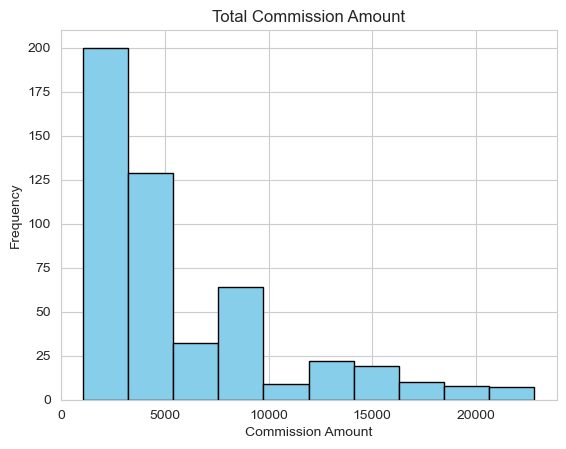

In [24]:
import matplotlib.pyplot as plt
import numpy as np
 
# Plotting a basic histogram
plt.hist(df['Commission_Amount'].sort_values(), bins=10, color='skyblue', edgecolor='black')
 
# Adding labels and title
plt.xlabel('Commission Amount')
plt.ylabel('Frequency')
plt.title('Total Commission Amount')
 
# Display the plot
plt.show()

In [32]:
df['Commission_Amount'].describe()

count      500.000000
mean      5752.115000
std       4709.442117
min       1050.000000
25%       2812.500000
50%       4080.000000
75%       8280.000000
max      22800.000000
Name: Commission_Amount, dtype: float64